# Final Project - Meng Cheng, Romell Lewis, Luis Henrique Spinola

# Final Project - Meng Cheng, Romell Lewis, Luis Henrique Spinola

## Introduction

Our analysis targets retail investors seeking to better understand the cryptocurrency asset class. We aim to demonstrate that cryptocurrencies are highly volatile investments and that returns across major coins are often significantly correlated with one another. Additionally, we also executed a prediction analysis using autoregression concepts. We aimed to predict the likely future performance of bitcoin, ultimately creating a signal for investors to either buy or sell the asset. Due to the high return correlation among cryptocurrencies, this prediction exercise can also be used as signals for either investing or shorting other cryptocurrencies.

To conduct this research, we used the CoinGecko API, which provides historical market price data for a wide range of cryptocurrencies. Using this data, we calculated logarithmic returns for the five largest cryptocurrencies by market relevance - Bitcoin, Ethereum, Solana, Binance Coin, and Ripple—over the past year. We then estimated the correlations among these assets and visualized them through a heatmap to highlight the degree of co-movement between different cryptocurrencies. We also reviewed the average performance of each of the cryptocurrency by month, found. We additionally analyzed the overall perfromance of all the unstable cryptocurrencies by month.

We also sought to illustrate how investors can digitize their wealth while mitigating the high volatility typically associated with cryptocurrencies. One potential alternative is investing in stablecoins - digital currencies designed to replicate the performance of the U.S. dollar. As demonstrated in our analysis, stablecoins exhibit minimal correlation with the price movements of more volatile cryptocurrencies. 

Thirdly, we examined the relationship between cryptocurrency performance and macroeconomic factors, particularly changes in U.S. interest rates. Using historical data from Yahoo Finance on the U.S. 10-year Treasury yield, we analyze how, during certain periods, Bitcoin - and, by extension, other cryptocurrencies - can exhibit an inverse relationship with changes in Treasury yields.

Finally, We conducted several analyses of bitcoin's performance over the last year. We built an ARIMA model to forecast the future performance of bitcoin. We showed the best performance and worst perfomance of btc as rolling violatility and days above the yearly average. 

In [1]:
!pip install arch

Defaulting to user installation because normal site-packages is not writeable


           Date         Price  log_return  coin_id
346  2026-02-19  66456.353762   -0.015426  bitcoin
347  2026-02-20  66918.684175    0.006933  bitcoin
348  2026-02-21  67970.294031    0.015593  bitcoin
349  2026-02-22  67977.909042    0.000112  bitcoin
350  2026-02-23  67585.117189   -0.005795  bitcoin
351  2026-02-24  64577.553201   -0.045521  bitcoin
352  2026-02-25  64074.110985   -0.007826  bitcoin
353  2026-02-26  67947.391856    0.058693  bitcoin
354  2026-02-27  67469.060403   -0.007065  bitcoin
355  2026-02-28  65883.990962   -0.023774  bitcoin
356  2026-03-01  67008.454357    0.016923  bitcoin
357  2026-03-02  65713.498989   -0.019514  bitcoin
358  2026-03-03  68864.036919    0.046830  bitcoin
359  2026-03-04  68321.617848   -0.007908  bitcoin
360  2026-03-05  72669.770165    0.061699  bitcoin
361  2026-03-06  70874.986871   -0.025008  bitcoin
362  2026-03-07  68148.283400   -0.039232  bitcoin
363  2026-03-08  67271.190778   -0.012954  bitcoin
364  2026-03-09  66036.157824  

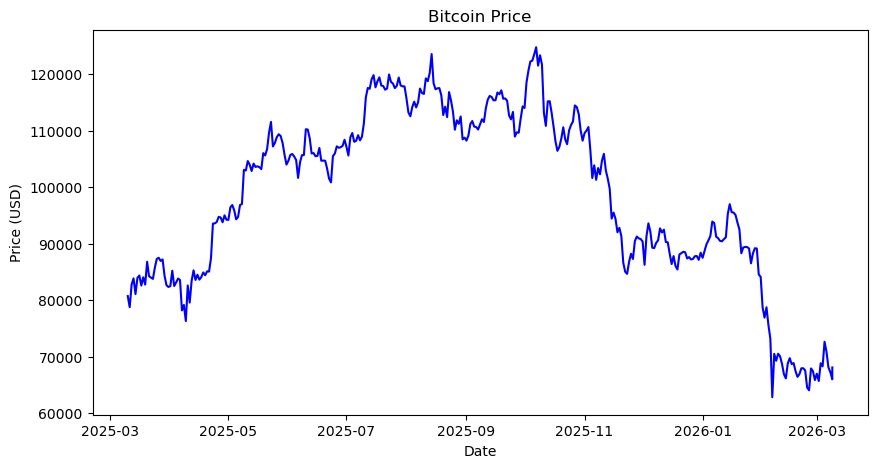

In [2]:
import requests
import json
from pprint import pprint
import pandas as pd
from datetime import datetime, timedelta
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import statsmodels.api as sm
import warnings

coin_ids = coin_ids = [
    "bitcoin",
    "ethereum",
    "tether",
    "binancecoin",     # BNB
    "ripple",          # XRP
    "solana"]

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    'vs_currency': 'usd',    
    'days': '365',           
    'interval': 'daily'      
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
 
    df = pd.DataFrame(data['prices'], columns=['Timestamp', 'Price'])
    df['Date'] = pd.to_datetime(df['Timestamp'], unit='ms').dt.date
    df['coin_id'] = 'bitcoin'
    df["log_return"] = np.log(df["Price"] / df["Price"].shift(1))
    df = df[["Date", "Price", "log_return","coin_id"]]
    pd.set_option('display.max_rows', None)

    print(df.tail(20))

    plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Price"], color="blue")

plt.title("Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

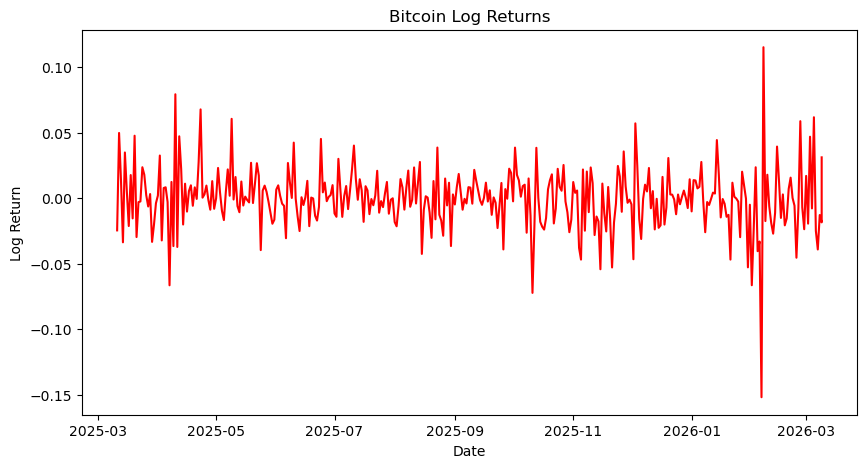

In [3]:
# When modelling a time series, it is important that the data exhibits stationarity, meaning that its statistical properties such as mean and variance remain relatively constant over time. As can be seen in the chart below, this is not the case with Bitcoin prices, which display strong trends and accentuated shifts in volatility. To address this issue, we transform the Bitcoin price series by computing the logarithmic returns of prices. This transformation removes the trend component and produces a new time series that fluctuates around a relatively constant mean and more stable variance, making it more suitable for time series modelling such as ARIMA and GARCH. 

plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["log_return"], color="red")

plt.title("Bitcoin Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

In [4]:
# After the transformation, we need to check whether the time series has become stationary. To perform the ADF test, we need to clean the data removing "NaN" values.

print(df.isna().sum())

Date          0
Price         0
log_return    1
coin_id       0
dtype: int64


In [5]:
# After cleaning the data and running the test, we can reject the hypothesis (H0) that the series is non-stationary. We can now estimate the ARIMA and GARCH models.

series = df["log_return"].dropna()
adf = adfuller(series)

print("ADF statistic:", adf[0])
print("p-value: ", "{:.2f}".format(adf[1]))
print("Used lags:", adf[2])
print("N obs:", adf[3])
print("Critical values:", adf[4])

ADF statistic: -21.29103889910212
p-value:  0.00
Used lags: 0
N obs: 364
Critical values: {'1%': np.float64(-3.4484434475193777), '5%': np.float64(-2.869513170510808), '10%': np.float64(-2.571017574266393)}


<Figure size 1000x500 with 0 Axes>

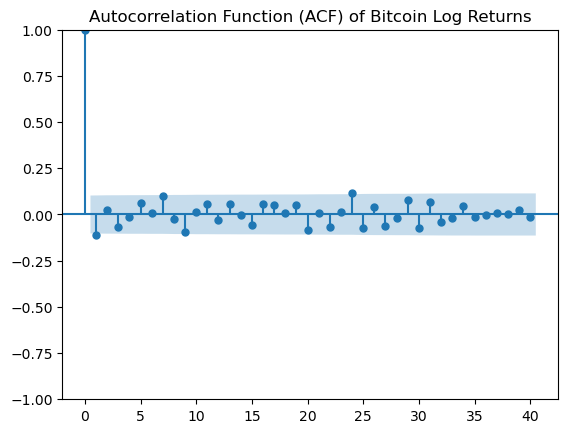

In [6]:
# With statistical significance that the time series is stationary, we now examine whether there is evidence of autocorrelation in the data. After running an Autocorrelation Function (ACF), one can see that there is no strong evidence of autocorrelation, as the correlation between points across different lags do not exceed the delimited thresholds.

from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10,5))
plot_acf(df["log_return"].dropna(), lags=40)
plt.title("Autocorrelation Function (ACF) of Bitcoin Log Returns")
plt.show()

In [7]:
# As the series is now stationary, we will build an ARIMA (p,0,q) model.

warnings.filterwarnings("ignore")

df = df.sort_values("Date")
df = df.set_index("Date")
r = df["log_return"].dropna()

from statsmodels.tsa.arima.model import ARIMA

best_ARIMA_aic = np.inf # AIC is a criterium to select the best possible model. The lower the AIC, the better. We then start at infinite AIC.
best_ARIMA_order = None # Will store the combination of (p,0,q) that best fits the model (lowest AIC)
best_ARIMA_res = None # Will store the object of the model (coefficients, residual, AIC, etc.)

# P is the number of autoregressive lags in the series. rt = c + ϕ1*rt−1 + ϕ2*rt−2 +...+ ϕp*rt−p +ϵt. It assumes that past returns help to explain the log_return of the asset for p periods, with their influence captured through the autoregressive coefficients (ϕ1, ϕ2, ϕp).
# Q is the moving average component of the series. rt = ϵt + θ1*ϵt−1 + θ2*ϵt−2 + ... + θq*ϵt−q. It assumes that past shocks (expressed by the residuals ϵ) affect the log_return of the assets for q periods.
# P and Q will determine the number of lagged terms in the ARIMA model. It will utlimately result in the number of variables used, so AIC will tell us to what extent makes sense adding more p or q to the model (p from 0 to 3; q from 0 to 3).

for p in range(0, 4):      # tests models with no autoregression (p=0) or with up to 3 variables (p=4).
    for q in range(0, 4):  # For each value of P, the model will also test values of q from 0 to 3. This will make a combinatorics analysis of 16 simulations. 
        if p == 0 and q == 0: # if ARIMA (0,0,0) -> white noise with average. Dont need to run the regression as no autogression nor moving average will influentiate in the variable going forward.
            continue
        try:
            res = ARIMA(r, order=(p,0,q)).fit() # runs the ARIMA regression 
            if res.aic < best_ARIMA_aic: # the model with the lowest AIC will be the best one
                best_ARIMA_aic = res.aic
                best_ARIMA_order = (p,0,q)
                best_ARIMA_res = res
        except:
            pass

print("Best ARIMA order:", best_ARIMA_order, "AIC:", best_ARIMA_aic)
print(best_ARIMA_res.summary())

Best ARIMA order: (1, 0, 0) AIC: -1705.3663909434904
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                  365
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 855.683
Date:                Mon, 09 Mar 2026   AIC                          -1705.366
Time:                        12:58:23   BIC                          -1693.667
Sample:                             0   HQIC                         -1700.717
                                - 365                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0005      0.001     -0.385      0.700      -0.003       0.002
ar.L1         -0.1130      0.032     -3.508      0.000      -0.176      -0.050

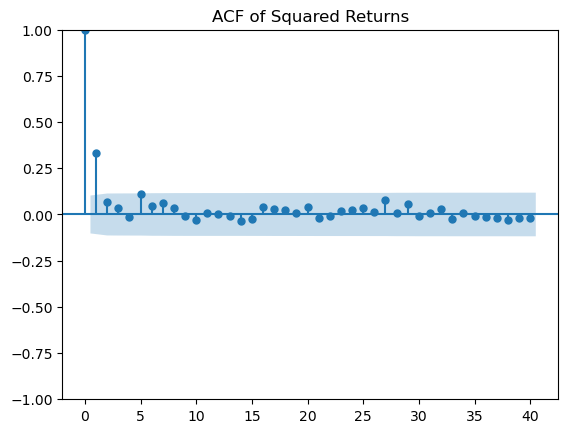

In [8]:
# The regression output indicates the presence of heteroskedasticity, meaning that the variance of the error term is not constant over time. Although the transformed return series does not exhibit significant autocorrelation, this does not rule out dependence in the variance of the series. In financial time series, it is common for volatility to display persistence, a phenomenon known as volatility clustering, where periods of high volatility tend to be followed by further periods of high volatility. Therefore, it is important to investigate whether such volatility clustering is present in the Bitcoin return series.
# To identify volatility clustering, we will run an autocorrelation analysis (ACF) on the square of the log_returns. If there is volatility clustering, then Corr(Rt^2, Rt-k^2)>0.

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(r**2, lags=40)
plt.title("ACF of Squared Returns")
plt.show()

In [9]:
# Final confirmation of volatility clustering made through ARCH LM test.

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(r) # Heteroskedasticity ARCH test
print("ARCH test p-value:", arch_test[1]) # Returns the P-value of the ARCH (Autoregressive Conditional Heteroskedasticity) Test

ARCH test p-value: 8.548126710787061e-08


In [10]:
# As the p-value in the last test was < 5%, there is statistical significance on volatility clustering. As a next step, a GARCH model will be exectued to help predicting the time series' future volatility.
# Variance equation modelled by GARCH: (σt)^2 = ω + A1*(ϵt−1)^2 + ... + Ap*(ϵt−p)^2 + β1*(σt−1)^2 + ... + βq*(σt−q)^2
# In a GARCH model, volatility depends on the squared past shocks (squared residuals (ϵt−1)^2 and on past conditional variances (σt−1)^2

warnings.filterwarnings("ignore")

r = df["log_return"].dropna() # Drops first NaN value

best_GARCH_aic = np.inf # AIC is a criterium to select the best possible model. The lower the AIC, the better. We then start at infinite AIC.
best_GARCH_order = None # Will store the combination of p and q that best fits the model (lowest AIC)
best_GARCH_res = None # Will store the object of the model (coefficients, residual, AIC, etc.)

# P is the number of autoregressive lags in the series. rt = w + A1*(ϵt−1)^2 + A2*(ϵt−p)^2  +...+ Ap*(ϵt−p)^2 + ϵt. It assumes that past returns help to explain the variance of the asset for p periods, with their influence captured through the autoregressive coefficients (A1, A2, Ap).
# Q is the moving average component of the series. rt = ϵt + θ1*ϵt−1 + θ2*ϵt−2 + ... + θq*ϵt−q. It assumes that past shocks (expressed by the residuals ϵ) affect the log_return of the assets for q periods.
# P and Q will determine the number of lagged terms in the GARCH model. It will utlimately result in the number of variables used, so AIC will tell us to what extent makes sense adding more Ps or Qs to the model (p from 0 to 3; q from 0 to 3).

for p in range(1, 4): # tests models with no autoregression (p=1) or with up to 3 variables (p=4).
    for q in range(1, 4): # For each value of P, the model will also test values of q from 1 to 4. This will make a combinatorics analysis of 16 simulations. 
        if p == 0 and q == 0:
            continue # avoid constant variance model GARCH (0,0,0)
        try:
            model = arch_model(r, mean="AR", lags=1, vol="GARCH", p=p, q=q) # runs the GARCH regression 
            res = model.fit(disp="off")
            print(f"AR(1)-GARCH({p},{q}) AIC:", res.aic)
            
            if res.aic < best_GARCH_aic:
                best_GARCH_aic = res.aic
                best_GARCH_order = (p,q)
                best_GARCH_res = res
        except:
            pass

print("\nBest GARCH order:", best_GARCH_order)
print("Best AIC:", best_GARCH_aic)
print(best_GARCH_res.summary())

AR(1)-GARCH(1,1) AIC: -1735.14164160877
AR(1)-GARCH(1,2) AIC: -1732.8728327469257
AR(1)-GARCH(1,3) AIC: -1728.0684132715196
AR(1)-GARCH(2,1) AIC: -1733.927528392499
AR(1)-GARCH(2,2) AIC: -1738.3096726951953
AR(1)-GARCH(2,3) AIC: -1732.3700395104813
AR(1)-GARCH(3,1) AIC: -1728.632686202558
AR(1)-GARCH(3,2) AIC: -1732.2695451901175
AR(1)-GARCH(3,3) AIC: -1730.7981076013411

Best GARCH order: (2, 2)
Best AIC: -1738.3096726951953
                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.004
Mean Model:                        AR   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:                876.155
Distribution:                  Normal   AIC:                          -1738.31
Method:            Maximum Likelihood   BIC:                          -1711.03
                                        No. Observations:                  364
Date:            

In [11]:
# The GARCH results indicate strong persistence in Bitcoin volatility, as the coefficient on the lagged conditional variance is highly significant. The ARCH term is only marginally significant, suggesting that volatility is primarily driven by its previous values rather than by previous observed shocks.
# As part of the next step in the analysis, forecasts in future expected returns and volatility will be made using the estimated regression coefficients for ARIMA and GARCH

# ARIMA forecast for conditional mean
arima_forecast = best_ARIMA_res.get_forecast(steps=1) # forecasts ARIMA for the following day
expected_return = arima_forecast.predicted_mean.iloc[0] # grabs the average of the predicted values. As we only predicted one, this is it

# GARCH forecast for conditional variance
garch_forecast = best_GARCH_res.forecast(horizon=1) # forecasts GARCH for the following day
expected_variance = garch_forecast.variance.iloc[-1, 0]
expected_volatility = expected_variance ** 0.5 # calculates volatility as the standard deviation

print("Expected return (t+1):", expected_return)
print("Expected variance (t+1):", expected_variance)
print("Expected volatility (t+1):", expected_volatility)

Expected return (t+1): -0.004032977303935544
Expected variance (t+1): 0.0007523078509640542
Expected volatility (t+1): 0.027428230912037586


In [12]:
# Based on the predicted values, an investment signal can be created determining whether Bitcoin should be bought or sold
# Calculate historical Log_return / volatility to arrive at a score

from scipy.stats import percentileofscore
warnings.filterwarnings("ignore")

# Series of log returns
r = df["log_return"].dropna()

# choose how many historical 1-step forecasts you want
walk_window = 360

# store results
walk_results = []

# start point so that we generate forecasts for the last 360 observations
start_idx = len(r) - walk_window - 1

for i in range(start_idx, len(r) - 1):
    
    # data available up to time t
    train = r.iloc[:i+1]
    
    # ---------- ARIMA forecast ----------
    arima_model = ARIMA(train, order=best_ARIMA_order)
    arima_res = arima_model.fit()
    forecast_return = arima_res.get_forecast(steps=1).predicted_mean.iloc[0]
    
    # ---------- GARCH forecast ----------
    garch_model = arch_model(
        train,
        mean="AR",
        lags=1,
        vol="GARCH",
        p=best_GARCH_order[0],
        q=best_GARCH_order[1]
    )
    garch_res = garch_model.fit(disp="off")
    forecast_variance = garch_res.forecast(horizon=1).variance.iloc[-1, 0]
    forecast_volatility = np.sqrt(forecast_variance)
    
    # ---------- Signal ----------
    forecast_signal = forecast_return / forecast_volatility
    
    # realized next-period return
    realized_return = r.iloc[i+1]
    
    walk_results.append({
        "Date": r.index[i+1],
        "forecast_return": forecast_return,
        "forecast_volatility": forecast_volatility,
        "forecast_signal": forecast_signal,
        "realized_return": realized_return
    })

walk_df = pd.DataFrame(walk_results).set_index("Date")

print(walk_df.tail())

# historical signal distribution
hist_signals = walk_df["forecast_signal"]

# current signal
current_signal = expected_return / expected_volatility

# percentile rank
signal_percentile = percentileofscore(hist_signals, current_signal)

print("Current signal:", current_signal)
print("Percentile rank:", signal_percentile)

            forecast_return  forecast_volatility  forecast_signal  \
Date                                                                
2026-03-06        -0.007414             0.031378        -0.236293   
2026-03-07         0.002611             0.028928         0.090268   
2026-03-08         0.004000             0.033579         0.119111   
2026-03-09         0.000892             0.027501         0.032422   
2026-03-09         0.001438             0.028968         0.049646   

            realized_return  
Date                         
2026-03-06        -0.025008  
2026-03-07        -0.039232  
2026-03-08        -0.012954  
2026-03-09        -0.018530  
2026-03-09         0.031090  
Current signal: -0.14703745629345596
Percentile rank: 6.388888888888889


In [13]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta
import time
import numpy as np
import matplotlib.pyplot as plt
import sqlite3 as sq
import sklearn
from sklearn.linear_model import LinearRegression

In [14]:
coin_ids = coin_ids = [
    "bitcoin",
    "ethereum",
    "tether",
    "binancecoin",     # BNB
    "ripple",          # XRP
    "solana"]
#Coins of interest

params = {
    'vs_currency': 'usd',    
    'days': '365',           
    'interval': 'daily'      
}

#Bitcoin dataframe
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
 
    btc_df = pd.DataFrame(data['prices'], columns=['Timestamp', 'Price'])
    btc_df['Date'] = pd.to_datetime(btc_df['Timestamp'], unit='ms')
    print("200")
    btc_df['coin_id']='bitcoin'
    print(btc_df.head())

200
       Timestamp         Price       Date  coin_id
0  1741564800000  80751.138933 2025-03-10  bitcoin
1  1741651200000  78783.940579 2025-03-11  bitcoin
2  1741737600000  82799.108029 2025-03-12  bitcoin
3  1741824000000  83884.245788 2025-03-13  bitcoin
4  1741910400000  81098.900524 2025-03-14  bitcoin


In [15]:
#eth dataframe
url2 = "https://api.coingecko.com/api/v3/coins/ethereum/market_chart"

response2 = requests.get(url2, params=params)

if response2.status_code == 200:
    data2 = response2.json()
 
    eth_df = pd.DataFrame(data2['prices'], columns=['Timestamp', 'Price'])
    eth_df['Date'] = pd.to_datetime(eth_df['Timestamp'], unit='ms')
    print("200")

eth_df['coin_id']='ethereum'

print(eth_df.head())

200
       Timestamp        Price       Date   coin_id
0  1741564800000  2017.265460 2025-03-10  ethereum
1  1741651200000  1879.123105 2025-03-11  ethereum
2  1741737600000  1921.309923 2025-03-12  ethereum
3  1741824000000  1910.655138 2025-03-13  ethereum
4  1741910400000  1862.794937 2025-03-14  ethereum


In [16]:
#Solana Dataframe

url3 = "https://api.coingecko.com/api/v3/coins/solana/market_chart"

response3 = requests.get(url3, params=params)

if response3.status_code == 200:
    data3 = response3.json()
 
    sol_df = pd.DataFrame(data3['prices'], columns=['Timestamp', 'Price'])
    sol_df['Date'] = pd.to_datetime(sol_df['Timestamp'], unit='ms')
    print("200")
    sol_df['coin_id']='solana'
    print(sol_df.head())

200
       Timestamp       Price       Date coin_id
0  1741564800000  126.634268 2025-03-10  solana
1  1741651200000  118.786444 2025-03-11  solana
2  1741737600000  125.428768 2025-03-12  solana
3  1741824000000  126.565365 2025-03-13  solana
4  1741910400000  123.237708 2025-03-14  solana


In [17]:
#Binancecoin (bnb) Dataframe

url4 = "https://api.coingecko.com/api/v3/coins/binancecoin/market_chart"

response4 = requests.get(url4, params=params)

if response4.status_code == 200:
    data4 = response4.json()
 
    bnb_df = pd.DataFrame(data4['prices'], columns=['Timestamp', 'Price'])
    bnb_df['Date'] = pd.to_datetime(bnb_df['Timestamp'], unit='ms')
    print("200")
    bnb_df['coin_id']='bnb'
    print(bnb_df.head())

200
       Timestamp       Price       Date coin_id
0  1741564800000  554.730004 2025-03-10     bnb
1  1741651200000  532.565881 2025-03-11     bnb
2  1741737600000  552.625428 2025-03-12     bnb
3  1741824000000  570.720770 2025-03-13     bnb
4  1741910400000  578.715621 2025-03-14     bnb


In [22]:
#Ripple (xrp) Dataframe 
url5 = "https://api.coingecko.com/api/v3/coins/ripple/market_chart"

response5 = requests.get(url5, params=params)

if response5.status_code == 200:
    data5 = response5.json()
 
    xrp_df = pd.DataFrame(data5['prices'], columns=['Timestamp', 'Price'])
    xrp_df['Date'] = pd.to_datetime(xrp_df['Timestamp'], unit='ms')
    print("200")
    xrp_df['coin_id']='ripple'
    print(xrp_df.head())

200
       Timestamp     Price       Date coin_id
0  1741564800000  2.136264 2025-03-10  ripple
1  1741651200000  2.029058 2025-03-11  ripple
2  1741737600000  2.169351 2025-03-12  ripple
3  1741824000000  2.241725 2025-03-13  ripple
4  1741910400000  2.250419 2025-03-14  ripple


In [23]:
#tether (USDT) dataframe

url6 = "https://api.coingecko.com/api/v3/coins/tether/market_chart"

response6 = requests.get(url6, params=params)

if response6.status_code == 200:
    data6 = response6.json()
 
    usdt_df = pd.DataFrame(data6['prices'], columns=['Timestamp', 'Price'])
    usdt_df['Date'] = pd.to_datetime(usdt_df['Timestamp'], unit='ms')
    print("200")
    usdt_df['coin_id']='tether'
    print(usdt_df.head())

200
       Timestamp     Price       Date coin_id
0  1741564800000  0.999694 2025-03-10  tether
1  1741651200000  0.999377 2025-03-11  tether
2  1741737600000  0.999731 2025-03-12  tether
3  1741824000000  0.999743 2025-03-13  tether
4  1741910400000  0.999535 2025-03-14  tether


In [24]:
#Create connection and cursor
conn = sq.connect('crypto.db') 
cursor = conn.cursor()

query = """DROP TABLE IF EXISTS crypto;"""

cursor.execute(query)

In [25]:
#convert dataferames to SQLITE
btc_df.to_sql("btc", conn, if_exists="replace", index=False)
eth_df.to_sql("eth", conn, if_exists="replace", index=False)
xrp_df.to_sql("xrp", conn, if_exists="replace", index=False)
sol_df.to_sql("sol", conn, if_exists="replace", index=False)
bnb_df.to_sql("bnb", conn, if_exists="replace", index=False)
usdt_df.to_sql("usdt", conn, if_exists="replace", index=False)

366

In [26]:
#check btc table created
btc_query = """SELECT * FROM btc LIMIT 10"""
btc = pd.read_sql(btc_query, conn)
btc

,Timestamp,Price,Date,coin_id
0,1741564800000,80751.138933,2025-03-10 00:00:00,bitcoin
1,1741651200000,78783.940579,2025-03-11 00:00:00,bitcoin
2,1741737600000,82799.108029,2025-03-12 00:00:00,bitcoin
3,1741824000000,83884.245788,2025-03-13 00:00:00,bitcoin
4,1741910400000,81098.900524,2025-03-14 00:00:00,bitcoin
5,1741996800000,83971.709161,2025-03-15 00:00:00,bitcoin
6,1742083200000,84391.690876,2025-03-16 00:00:00,bitcoin
7,1742169600000,82610.617503,2025-03-17 00:00:00,bitcoin
8,1742256000000,84075.365597,2025-03-18 00:00:00,bitcoin
9,1742342400000,82780.030487,2025-03-19 00:00:00,bitcoin


In [27]:
#join btc to eth (query)
btc_eth_query = """SELECT btc.date, btc.price AS btc_price, eth.price AS eth_price FROM btc 
                    JOIN eth ON btc.Date=eth.Date"""
btc_eth = pd.read_sql(btc_eth_query, conn)
btc_eth.head()

,Date,btc_price,eth_price
0,2025-03-10 00:00:00,80751.138933,2017.265460
1,2025-03-11 00:00:00,78783.940579,1879.123105
2,2025-03-12 00:00:00,82799.108029,1921.309923
3,2025-03-13 00:00:00,83884.245788,1910.655138
4,2025-03-14 00:00:00,81098.900524,1862.794937


In [28]:
btc_eth.to_sql("btc_eth", conn, if_exists="replace", index=False)

366

In [29]:
#join btc_eth to xrp
btc_eth_xrp_query = """SELECT btc_eth.Date, btc_eth.btc_price, btc_eth.eth_price, xrp.Price AS xrp_price FROM btc_eth 
                    JOIN xrp ON btc_eth.Date=xrp.Date"""
btc_eth_xrp = pd.read_sql(btc_eth_xrp_query, conn)
btc_eth_xrp.head()

,Date,btc_price,eth_price,xrp_price
0,2025-03-10 00:00:00,80751.138933,2017.265460,2.136264
1,2025-03-11 00:00:00,78783.940579,1879.123105,2.029058
2,2025-03-12 00:00:00,82799.108029,1921.309923,2.169351
3,2025-03-13 00:00:00,83884.245788,1910.655138,2.241725
4,2025-03-14 00:00:00,81098.900524,1862.794937,2.250419


In [30]:
btc_eth_xrp.to_sql("btc_eth_xrp", conn, if_exists="replace", index=False)

365

In [31]:
#Join the rest of the cryptocurrencies
all_crypto_query =  """SELECT btc_eth_xrp.Date, btc_eth_xrp.btc_price, btc_eth_xrp.eth_price, btc_eth_xrp.xrp_price, 
                        sol.Price AS sol_price, bnb.Price AS bnb_price, usdt.Price AS usdt_price
                        FROM btc_eth_xrp
                        JOIN sol ON btc_eth_xrp.Date=sol.Date
                        JOIN bnb ON btc_eth_xrp.Date=bnb.Date
                        JOIN usdt ON btc_eth_xrp.Date=usdt.Date"""
all_crypto = pd.read_sql(all_crypto_query, conn)
all_crypto.head()

,Date,btc_price,eth_price,xrp_price,sol_price,bnb_price,usdt_price
0,2025-03-10 00:00:00,80751.138933,2017.265460,2.136264,126.634268,554.730004,0.999694
1,2025-03-11 00:00:00,78783.940579,1879.123105,2.029058,118.786444,532.565881,0.999377
2,2025-03-12 00:00:00,82799.108029,1921.309923,2.169351,125.428768,552.625428,0.999731
3,2025-03-13 00:00:00,83884.245788,1910.655138,2.241725,126.565365,570.720770,0.999743
4,2025-03-14 00:00:00,81098.900524,1862.794937,2.250419,123.237708,578.715621,0.999535


In [32]:
all_crypto.to_sql("btc_eth_xrp", conn, if_exists="replace", index=False)

365

In [33]:
price_cols = [
    "btc_price",
    "eth_price",
    "xrp_price",
    "sol_price",
    "bnb_price",
    "usdt_price"
]

for col in price_cols:
    all_crypto[col + "_logret"] = np.log(all_crypto[col] / all_crypto[col].shift(1))

all_crypto.head()

,Date,btc_price,eth_price,xrp_price,sol_price,bnb_price,usdt_price,btc_price_logret,eth_price_logret,xrp_price_logret,sol_price_logret,bnb_price_logret,usdt_price_logret
0,2025-03-10 00:00:00,80751.138933,2017.265460,2.136264,126.634268,554.730004,0.999694,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-03-11 00:00:00,78783.940579,1879.123105,2.029058,118.786444,532.565881,0.999377,-0.024663,-0.070938,-0.051487,-0.063976,-0.040775,-0.000317
2,2025-03-12 00:00:00,82799.108029,1921.309923,2.169351,125.428768,552.625428,0.999731,0.049708,0.022202,0.066856,0.054411,0.036974,0.000355
3,2025-03-13 00:00:00,83884.245788,1910.655138,2.241725,126.565365,570.720770,0.999743,0.013021,-0.005561,0.032818,0.009021,0.032220,0.000011
4,2025-03-14 00:00:00,81098.900524,1862.794937,2.250419,123.237708,578.715621,0.999535,-0.033768,-0.025368,0.003871,-0.026644,0.013911,-0.000207


In [34]:
all_crypto.to_sql("crypto_returns", conn, if_exists="replace", index=False)

365

In [35]:
#Check if crypto return table functinoal
crypto_returns_query = """SELECT * FROM crypto_returns"""

crypto_returns = pd.read_sql(crypto_returns_query, conn)
crypto_returns.head(10)

,Date,btc_price,eth_price,xrp_price,sol_price,bnb_price,usdt_price,btc_price_logret,eth_price_logret,xrp_price_logret,sol_price_logret,bnb_price_logret,usdt_price_logret
0,2025-03-10 00:00:00,80751.138933,2017.265460,2.136264,126.634268,554.730004,0.999694,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-03-11 00:00:00,78783.940579,1879.123105,2.029058,118.786444,532.565881,0.999377,-0.024663,-0.070938,-0.051487,-0.063976,-0.040775,-0.000317
2,2025-03-12 00:00:00,82799.108029,1921.309923,2.169351,125.428768,552.625428,0.999731,0.049708,0.022202,0.066856,0.054411,0.036974,0.000355
3,2025-03-13 00:00:00,83884.245788,1910.655138,2.241725,126.565365,570.720770,0.999743,0.013021,-0.005561,0.032818,0.009021,0.032220,0.000011
4,2025-03-14 00:00:00,81098.900524,1862.794937,2.250419,123.237708,578.715621,0.999535,-0.033768,-0.025368,0.003871,-0.026644,0.013911,-0.000207
5,2025-03-15 00:00:00,83971.709161,1910.666270,2.356413,133.554535,586.970250,1.000009,0.034811,0.025374,0.046024,0.080395,0.014163,0.000474
6,2025-03-16 00:00:00,84391.690876,1939.785688,2.392286,135.838081,618.766635,1.000019,0.004989,0.015125,0.015109,0.016954,0.052754,0.000010
7,2025-03-17 00:00:00,82610.617503,1887.764343,2.300910,126.165145,602.015350,0.999900,-0.021331,-0.027184,-0.038945,-0.073872,-0.027445,-0.000119
8,2025-03-18 00:00:00,84075.365597,1929.183358,2.340801,128.279810,630.446954,0.999932,0.017575,0.021704,0.017188,0.016622,0.046146,0.000032
9,2025-03-19 00:00:00,82780.030487,1932.796406,2.289348,125.344060,628.621410,0.999795,-0.015527,0.001871,-0.022226,-0.023151,-0.002900,-0.000137


In [36]:
#BTC Positive Dates
btc_positive_return_days_query = """SELECT COUNT(Date)
                                    FROM crypto_returns
                                    WHERE btc_price_logret >0"""

btc_positive_return_days = pd.read_sql(btc_positive_return_days_query, conn)
btc_positive_return_days

,COUNT(Date)
0,177


In [37]:
#Highest and lowest return date of BTC
peaks_btc_query = """SELECT MAX(btc_price_logret), MIN (btc_price_logret)
                        FROM crypto_returns"""
peaks_btc = pd.read_sql(peaks_btc_query, conn)
peaks_btc

,MAX(btc_price_logret),MIN (btc_price_logret)
0,0.115143,-0.152007


In [38]:
#Validate above finding
high_btc_query = """SELECT Date, btc_price_logret
                        FROM crypto_returns
                        ORDER BY btc_price_logret DESC
                        LIMIT 5"""
high_btc = pd.read_sql(high_btc_query, conn)
high_btc

,Date,btc_price_logret
0,2026-02-07 00:00:00,0.115143
1,2025-04-10 00:00:00,0.079224
2,2025-04-23 00:00:00,0.067685
3,2026-03-05 00:00:00,0.061699
4,2025-05-09 00:00:00,0.060485


In [39]:
#Validate above finding
low_btc_query = """SELECT Date, btc_price_logret
                        FROM crypto_returns
                        ORDER BY btc_price_logret ASC
                        LIMIT 5"""
low_btc = pd.read_sql(low_btc_query, conn)
low_btc

,Date,btc_price_logret
0,2025-03-10 00:00:00,NaN
1,2026-02-06 00:00:00,-0.152007
2,2025-10-11 00:00:00,-0.072371
3,2025-04-07 00:00:00,-0.066578
4,2026-02-01 00:00:00,-0.066532


In [40]:
#average returns by currency grouped by month
monthly_query = """
SELECT 
    strftime('%Y-%m', Date) AS month,
    AVG(btc_price_logret) AS avg_btc_return,
    AVG(eth_price_logret) AS avg_eth_return,
    AVG(xrp_price_logret) AS avg_xrp_return,
    AVG(sol_price_logret) AS avg_sol_return,
    AVG(bnb_price_logret) AS avg_bnb_return,
    AVG(usdt_price_logret) AS avg_usdt_return
FROM crypto_returns
GROUP BY month
ORDER BY month
"""

monthly_btc = pd.read_sql(monthly_query, conn)
monthly_btc

,month,avg_btc_return,avg_eth_return,avg_xrp_return,avg_sol_return,avg_bnb_return,avg_usdt_return
0,2025-03,0.000937,-0.005285,-0.000007,-0.000779,0.003852,4.512994e-06
1,2025-04,0.004499,-0.000155,0.001585,0.005401,-0.000049,1.610011e-05
2,2025-05,0.003177,0.010966,-0.001437,0.002134,0.002857,-7.634987e-07
3,2025-06,0.001377,-0.000289,0.001008,-0.000687,-0.000057,-4.178620e-06
4,2025-07,0.002693,0.013535,0.010941,0.004793,0.006199,-7.113032e-06
5,2025-08,-0.002578,0.004470,-0.003088,0.004215,0.002653,9.963321e-06
6,2025-09,0.001652,-0.001225,0.000766,0.001639,0.005939,9.674723e-06
7,2025-10,-0.001760,-0.003329,-0.005407,-0.004660,0.001490,-1.147806e-05
8,2025-11,-0.005841,-0.007997,-0.003372,-0.010106,-0.007024,6.524775e-06
9,2025-12,-0.000873,-0.000229,-0.005196,-0.002779,-0.000499,-4.267115e-05


In [41]:
#Python Groupby average returns by currency grouped by month
crypto_returns['Date'] = pd.to_datetime(crypto_returns['Date'])
crypto_returns['month'] = crypto_returns['Date'].dt.strftime('%Y-%m')
monthly_btc_python_returns = (crypto_returns.groupby('month')[[
            'btc_price_logret',
            'eth_price_logret',
            'xrp_price_logret',
            'sol_price_logret',
            'bnb_price_logret',
            'usdt_price_logret']].mean().reset_index())
monthly_btc_python_returns = monthly_btc_python_returns.sort_values('month')

#rename columns
monthly_btc_python_returns = monthly_btc_python_returns.rename(columns={
    'btc_price_logret': 'avg_btc_return',
    'eth_price_logret': 'avg_eth_return',
    'xrp_price_logret': 'avg_xrp_return',
    'sol_price_logret': 'avg_sol_return',
    'bnb_price_logret': 'avg_bnb_return',
    'usdt_price_logret': 'avg_usdt_return'})

monthly_btc_python_returns 

,month,avg_btc_return,avg_eth_return,avg_xrp_return,avg_sol_return,avg_bnb_return,avg_usdt_return
0,2025-03,0.000937,-0.005285,-0.000007,-0.000779,0.003852,4.512994e-06
1,2025-04,0.004499,-0.000155,0.001585,0.005401,-0.000049,1.610011e-05
2,2025-05,0.003177,0.010966,-0.001437,0.002134,0.002857,-7.634987e-07
3,2025-06,0.001377,-0.000289,0.001008,-0.000687,-0.000057,-4.178620e-06
4,2025-07,0.002693,0.013535,0.010941,0.004793,0.006199,-7.113032e-06
5,2025-08,-0.002578,0.004470,-0.003088,0.004215,0.002653,9.963321e-06
6,2025-09,0.001652,-0.001225,0.000766,0.001639,0.005939,9.674723e-06
7,2025-10,-0.001760,-0.003329,-0.005407,-0.004660,0.001490,-1.147806e-05
8,2025-11,-0.005841,-0.007997,-0.003372,-0.010106,-0.007024,6.524775e-06
9,2025-12,-0.000873,-0.000229,-0.005196,-0.002779,-0.000499,-4.267115e-05


In [42]:
#Tidy data
logret_cols = [
    "btc_price_logret" ,
    "eth_price_logret",
    "xrp_price_logret",
    "sol_price_logret",
    "bnb_price_logret",
    "usdt_price_logret"
]

tidy_all_crypto_df = all_crypto.melt(
    id_vars="Date",
    value_vars=logret_cols,
    var_name="coin_id",
    value_name="log_return"
)

tidy_all_crypto_df["coin_id"] = (
    tidy_all_crypto_df["coin_id"]
    .str.replace("_price_logret", "", regex=False)
)

print(tidy_all_crypto_df.head(10))
print(tidy_all_crypto_df.tail(10))

                  Date coin_id  log_return
0  2025-03-10 00:00:00     btc         NaN
1  2025-03-11 00:00:00     btc   -0.024663
2  2025-03-12 00:00:00     btc    0.049708
3  2025-03-13 00:00:00     btc    0.013021
4  2025-03-14 00:00:00     btc   -0.033768
5  2025-03-15 00:00:00     btc    0.034811
6  2025-03-16 00:00:00     btc    0.004989
7  2025-03-17 00:00:00     btc   -0.021331
8  2025-03-18 00:00:00     btc    0.017575
9  2025-03-19 00:00:00     btc   -0.015527
                     Date coin_id  log_return
2180  2026-02-28 00:00:00    usdt   -0.000007
2181  2026-03-01 00:00:00    usdt    0.000317
2182  2026-03-02 00:00:00    usdt   -0.000306
2183  2026-03-03 00:00:00    usdt   -0.000013
2184  2026-03-04 00:00:00    usdt   -0.000002
2185  2026-03-05 00:00:00    usdt    0.000095
2186  2026-03-06 00:00:00    usdt   -0.000082
2187  2026-03-07 00:00:00    usdt   -0.000087
2188  2026-03-08 00:00:00    usdt    0.000020
2189  2026-03-09 00:00:00    usdt    0.000039


In [43]:
tidy_all_crypto_df.to_sql("tidy_crypto_returns",conn, if_exists="replace", index=False)

2190

In [44]:
#Highest average return days for all unstable crypto
high_avg_unstable_query = """SELECT Date, AVG(log_return)
                            FROM tidy_crypto_returns
                            WHERE coin_id!= 'usdt'
                            GROUP BY Date 
                            ORDER BY AVG(log_return) DESC
                            LIMIT 10"""

high_avg_unstable = pd.read_sql(high_avg_unstable_query, conn)
high_avg_unstable

,Date,AVG(log_return)
0,2026-02-07 00:00:00,0.124104
1,2025-04-10 00:00:00,0.101441
2,2025-05-09 00:00:00,0.097026
3,2025-10-13 00:00:00,0.086674
4,2025-08-23 00:00:00,0.084608
5,2026-02-26 00:00:00,0.078837
6,2025-04-23 00:00:00,0.072870
7,2025-06-24 00:00:00,0.066872
8,2025-12-03 00:00:00,0.066595
9,2025-03-20 00:00:00,0.056925


In [45]:
#Python Groupby Highest average return days for all unstable crypto
high_avg_python_unstable = (
    tidy_all_crypto_df[tidy_all_crypto_df["coin_id"] != "usdt"].groupby("Date")["log_return"].mean().sort_values(ascending=False).reset_index())

high_avg_python_unstable.head(10)

,Date,log_return
0,2026-02-07 00:00:00,0.124104
1,2025-04-10 00:00:00,0.101441
2,2025-05-09 00:00:00,0.097026
3,2025-10-13 00:00:00,0.086674
4,2025-08-23 00:00:00,0.084608
5,2026-02-26 00:00:00,0.078837
6,2025-04-23 00:00:00,0.072870
7,2025-06-24 00:00:00,0.066872
8,2025-12-03 00:00:00,0.066595
9,2025-03-20 00:00:00,0.056925


In [46]:
#apply good return or bad return day for unstable crypto on positive of negative days
def performance_status(log_return):
    return 'Good' if log_return >0 else 'Bad'

high_avg_python_unstable['Performance_status'] = high_avg_python_unstable['log_return'].apply(performance_status)
high_avg_python_unstable.sample(10)

,Date,log_return,Performance_status
13,2025-08-08 00:00:00,0.049549,Good
332,2025-03-17 00:00:00,-0.037755,Bad
206,2025-05-01 00:00:00,-0.003195,Bad
326,2025-06-22 00:00:00,-0.036219,Bad
352,2025-06-06 00:00:00,-0.052104,Bad
252,2026-03-02 00:00:00,-0.013020,Bad
164,2026-01-17 00:00:00,0.002629,Good
310,2025-08-22 00:00:00,-0.030331,Bad
97,2025-09-17 00:00:00,0.014789,Good
107,2025-10-20 00:00:00,0.013304,Good


In [47]:
#pivot table for returns by date
returns_wide =  tidy_all_crypto_df.pivot(index='Date', columns='coin_id', values='log_return')
returns_wide.head(10)

coin_id,bnb,btc,eth,sol,usdt,xrp
Date,,,,,,
2025-03-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-11 00:00:00,-0.040775,-0.024663,-0.070938,-0.063976,-0.000317,-0.051487
2025-03-12 00:00:00,0.036974,0.049708,0.022202,0.054411,0.000355,0.066856
2025-03-13 00:00:00,0.032220,0.013021,-0.005561,0.009021,0.000011,0.032818
2025-03-14 00:00:00,0.013911,-0.033768,-0.025368,-0.026644,-0.000207,0.003871
2025-03-15 00:00:00,0.014163,0.034811,0.025374,0.080395,0.000474,0.046024
2025-03-16 00:00:00,0.052754,0.004989,0.015125,0.016954,0.000010,0.015109
2025-03-17 00:00:00,-0.027445,-0.021331,-0.027184,-0.073872,-0.000119,-0.038945
2025-03-18 00:00:00,0.046146,0.017575,0.021704,0.016622,0.000032,0.017188


In [48]:
#correlation matrix for coins
corr_matrix = returns_wide[['btc','eth','bnb','xrp','sol','usdt']].corr()
print(corr_matrix)

coin_id       btc       eth       bnb       xrp       sol      usdt
coin_id                                                            
btc      1.000000  0.844928  0.741663  0.827458  0.834782  0.293216
eth      0.844928  1.000000  0.760930  0.798985  0.870751  0.222542
bnb      0.741663  0.760930  1.000000  0.696945  0.760993  0.103825
xrp      0.827458  0.798985  0.696945  1.000000  0.816402  0.271383
sol      0.834782  0.870751  0.760993  0.816402  1.000000  0.238648
usdt     0.293216  0.222542  0.103825  0.271383  0.238648  1.000000


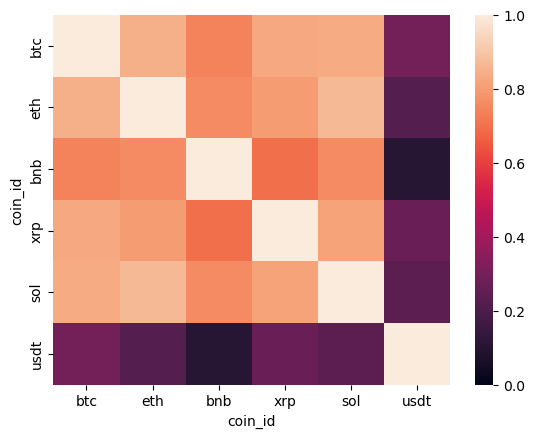

In [49]:
#Heatmap comparing coins
import seaborn as sns

sns.heatmap(corr_matrix, vmin=0, vmax=1);

In [50]:
all_crypto.describe()

,btc_price,eth_price,xrp_price,sol_price,bnb_price,usdt_price,btc_price_logret,eth_price_logret,xrp_price_logret,sol_price_logret,bnb_price_logret,usdt_price_logret
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,364.000000,364.000000,364.000000,364.000000,364.000000,3.640000e+02
mean,98358.855558,2989.768860,2.318082,153.608813,790.514794,0.999968,-0.000553,-0.000109,-0.001277,-0.001205,0.000270,8.932626e-07
std,15390.373866,907.669982,0.496416,38.321935,171.759660,0.000499,0.023362,0.039203,0.038492,0.040752,0.027872,2.401348e-04
min,62853.690384,1471.360885,1.216111,77.742397,532.565881,0.997961,-0.152007,-0.167289,-0.221114,-0.161856,-0.144916,-8.470613e-04
25%,87305.956560,2125.834586,2.044921,128.279810,639.597977,0.999694,-0.012425,-0.019881,-0.021453,-0.025578,-0.013546,-1.264025e-04
50%,102290.137147,2950.912849,2.234340,147.972139,786.480720,1.000058,-0.000458,0.000034,-0.003003,-0.001648,0.002025,-2.122142e-06
75%,110997.804371,3765.453624,2.645882,180.386383,895.397923,1.000298,0.011423,0.017394,0.016410,0.021078,0.014000,1.093247e-04
max,124773.508231,4829.225542,3.556293,247.556262,1311.712915,1.001698,0.115143,0.193846,0.188979,0.120228,0.132052,1.165190e-03


In [51]:
all_crypto.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               365 non-null    str    
 1   btc_price          365 non-null    float64
 2   eth_price          365 non-null    float64
 3   xrp_price          365 non-null    float64
 4   sol_price          365 non-null    float64
 5   bnb_price          365 non-null    float64
 6   usdt_price         365 non-null    float64
 7   btc_price_logret   364 non-null    float64
 8   eth_price_logret   364 non-null    float64
 9   xrp_price_logret   364 non-null    float64
 10  sol_price_logret   364 non-null    float64
 11  bnb_price_logret   364 non-null    float64
 12  usdt_price_logret  364 non-null    float64
dtypes: float64(12), str(1)
memory usage: 44.0 KB


In [52]:
#This query checks the SQLite database and lists all existing tables.
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

,name
0,btc
1,eth
2,xrp
3,sol
4,bnb
5,usdt
6,btc_eth
7,btc_eth_xrp
8,crypto_returns
9,tidy_crypto_returns


In [53]:
pd.read_sql("PRAGMA table_info(crypto_returns);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Date,TEXT,0,None,0
1,1,btc_price,REAL,0,None,0
2,2,eth_price,REAL,0,None,0
3,3,xrp_price,REAL,0,None,0
4,4,sol_price,REAL,0,None,0
5,5,bnb_price,REAL,0,None,0
6,6,usdt_price,REAL,0,None,0
7,7,btc_price_logret,REAL,0,None,0
8,8,eth_price_logret,REAL,0,None,0
9,9,xrp_price_logret,REAL,0,None,0


In [63]:
#This query calculates Bitcoin’s 30-day rolling volatility by taking the average absolute price change over the previous 30 days for each date.

query = """
SELECT
    c1.Date,
    c1.btc_price_logret,
    (
        SELECT AVG(c2.btc_price_logret * c2.btc_price_logret) - 
               AVG(c2.btc_price_logret) * AVG(c2.btc_price_logret)
        FROM crypto_returns c2
        WHERE date(c2.Date) BETWEEN date(c1.Date,'-30 day') AND date(c1.Date)
    ) AS rolling_volatility
FROM crypto_returns c1
ORDER BY c1.Date
"""

pd.read_sql(query,conn).tail(20)

,Date,btc_price_logret,rolling_volatility
345,2026-02-18 00:00:00,-0.020798,0.001679
346,2026-02-19 00:00:00,-0.015426,0.001679
347,2026-02-20 00:00:00,0.006933,0.001689
348,2026-02-21 00:00:00,0.015593,0.001664
349,2026-02-22 00:00:00,0.000112,0.001653
350,2026-02-23 00:00:00,-0.005795,0.001650
351,2026-02-24 00:00:00,-0.045521,0.001689
352,2026-02-25 00:00:00,-0.007826,0.001687
353,2026-02-26 00:00:00,0.058693,0.001822
354,2026-02-27 00:00:00,-0.007065,0.001796


In [66]:
import pandas as pd
import numpy as np

df = pd.read_sql("SELECT Date, btc_price_logret FROM crypto_returns", conn)
df['Date'] = pd.to_datetime(df['Date'])

# 30-day rolling volatility
df['rolling_volatility'] = df['btc_price_logret'].rolling(30).var()

df.tail(20)

,Date,btc_price_logret,rolling_volatility
345,2026-02-18,-0.020798,0.001794
346,2026-02-19,-0.015426,0.001795
347,2026-02-20,0.006933,0.001758
348,2026-02-21,0.015593,0.001764
349,2026-02-22,0.000112,0.001764
350,2026-02-23,-0.005795,0.001761
351,2026-02-24,-0.045521,0.001803
352,2026-02-25,-0.007826,0.001790
353,2026-02-26,0.058693,0.001920
354,2026-02-27,-0.007065,0.001907


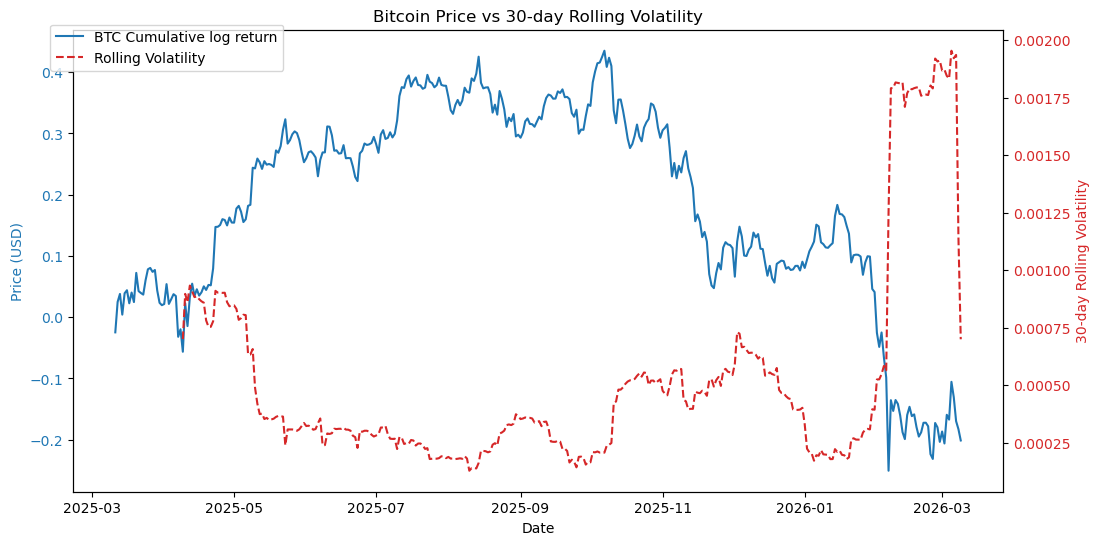

In [67]:
import pandas as pd
import matplotlib.pyplot as plt


df['Date'] = pd.to_datetime(df['Date'])


fig, ax1 = plt.subplots(figsize=(12,6))


color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)', color=color)
ax1.plot(df['Date'], df['btc_price_logret'].cumsum(), color=color, label='BTC Cumulative log return')
ax1.tick_params(axis='y', labelcolor=color)


ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('30-day Rolling Volatility', color=color)
ax2.plot(df['Date'], df['rolling_volatility'], color=color, linestyle='--', label='Rolling Volatility')
ax2.tick_params(axis='y', labelcolor=color)


plt.title("Bitcoin Price vs 30-day Rolling Volatility")

fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.show()

In [59]:
#This query finds all Bitcoin dates where the price is above the average price.
query = """
SELECT
    Date,
    Price
    FROM btc
    WHERE Price >
      (
        SELECT AVG(Price)
        FROM btc
      )
ORDER BY Price DESC
"""

pd.read_sql(query, conn).tail(20)

df_price = pd.read_sql(query, conn)


df_price.tail(20)

,Date,Price
170,2025-05-12 00:00:00,103994.061617
171,2025-11-06 00:00:00,103877.959660
172,2025-05-16 00:00:00,103708.851364
173,2025-05-15 00:00:00,103594.425751
174,2025-05-17 00:00:00,103556.034940
175,2025-11-08 00:00:00,103396.084216
176,2025-06-21 00:00:00,103290.105145
177,2025-05-18 00:00:00,103212.364839
178,2025-05-09 00:00:00,103076.275555
179,2025-05-10 00:00:00,102962.540457


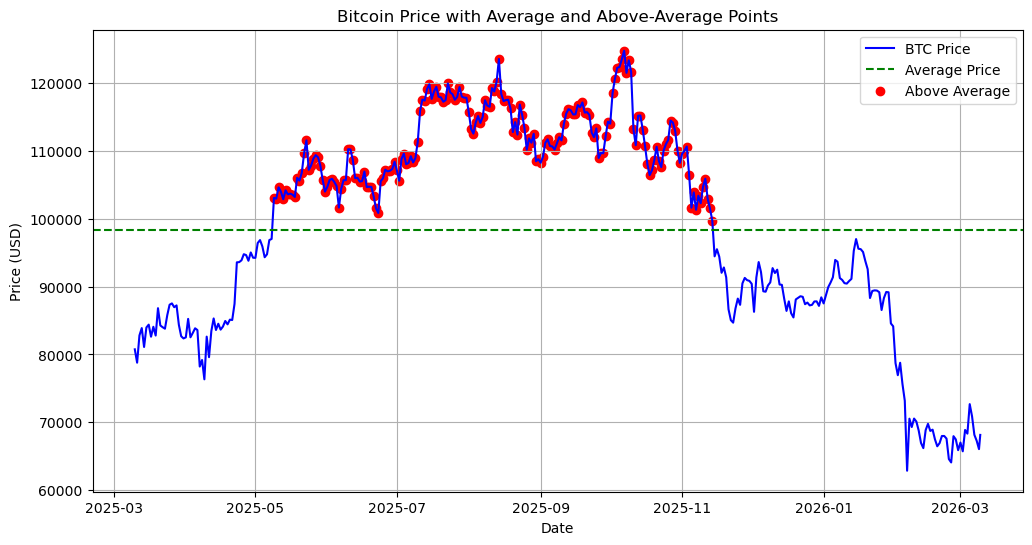

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

query_all = "SELECT Date, Price FROM btc ORDER BY Date"
df_price = pd.read_sql(query_all, conn)


df_price['Date'] = pd.to_datetime(df_price['Date'])


avg_price = df_price['Price'].mean()


df_price['above_avg'] = df_price['Price'] > avg_price


plt.figure(figsize=(12,6))


plt.plot(df_price['Date'], df_price['Price'], color='blue', label='BTC Price')


plt.axhline(y=avg_price, color='green', linestyle='--', label='Average Price')


plt.scatter(df_price.loc[df_price['above_avg'], 'Date'],
            df_price.loc[df_price['above_avg'], 'Price'],
            color='red', label='Above Average')


plt.title('Bitcoin Price with Average and Above-Average Points')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.show()

## Conclusion

When comparing multiple cryptocurrencies, we observed that they exhibited little to no correlation with the U.S. dollar and only moderate correlations with one another, as illustrated in the heatmap. Monthly returns also varied substantially across individual coins, indicating significant heterogeneity in performance within the cryptocurrency market. When analyzing the unstable coins as a group, we found that their strongest collective performance occurred on February 7th. This suggests that market events occurring on that date may have influenced broad cryptocurrency performance and may warrant further investigation when identifying predictors of high returns.

Focusing specifically on Bitcoin, we found that it generated positive daily returns on 177 days, representing approximately 48% of the year. Its highest single-day return was 11.5%, while its lowest was −15%. The return series also displayed clear volatility clustering, a common characteristic of financial markets in which periods of high volatility are followed by additional volatile periods. Additionally, Bitcoin exhibited extended periods of deviation from its mean return accompanied by sustained price trends.

In our model analysis, we generate a trading signal for the following day (t+1). By also generating historical signals using only the information available at each prior time point, we are able to evaluate the relative strength of the current signal. Specifically, we compare the current signal to the distribution of past signals. If the current signal is at or above the 50th percentile of historical signals, we classify it as sufficiently strong to warrant an investment decision.